# LLM Performance Report


## Setup


In [5]:
import importlib, subprocess, sys
try:
    importlib.import_module("requests")
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "--break-system-packages", "-q", "requests"], check=True)

import os, time, statistics as stats
import requests
import pandas as pd
import matplotlib.pyplot as plt

try:
    from config import HF_API_TOKEN, MODEL_NAME
    print(f"Loaded config.py — model: {MODEL_NAME}")
except ImportError:
    import getpass
    HF_API_TOKEN = os.environ.get("HF_API_TOKEN") or getpass.getpass("HF_API_TOKEN: ")
    MODEL_NAME = os.environ.get("MODEL_NAME") or input("MODEL_NAME: ")
    print(f"Using model: {MODEL_NAME}")

def query_llm(prompt: str) -> str:
    url = "https://router.huggingface.co/v1/chat/completions"
    headers = {"Authorization": f"Bearer {HF_API_TOKEN}", "Content-Type": "application/json"}
    payload = {
        "model": MODEL_NAME,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 200,
        "temperature": 0.2,
    }
    response = requests.post(url, headers=headers, json=payload, timeout=30)
    if response.status_code != 200:
        raise RuntimeError(f"Hugging Face API Error ({response.status_code}): {response.text}")
    return response.json()["choices"][0]["message"]["content"].strip()

Loaded config.py — model: meta-llama/Llama-3.1-8B-Instruct


## Run test prompts and evaluate

In [6]:
TEST_PROMPTS = [
    "What are the symptoms of migraine?",
    "What causes high blood pressure?",
    "How is a fever treated at home?",
    "What are the early signs of diabetes?",
    "What is the recommended treatment for a common cold?",
]

rows = []
for p in TEST_PROMPTS:
    t0 = time.perf_counter()
    try:
        answer = query_llm(p)
        latency = time.perf_counter() - t0
        n_words = len(answer.split())
        rows.append({
            "prompt": p,
            "latency_s": round(latency, 2),
            "words_generated": n_words,
            "words_per_sec": round(n_words / latency, 1) if latency else None,
            "answer_preview": (answer[:70] + "...") if len(answer) > 70 else answer,
        })
    except Exception as e:
        rows.append({"prompt": p, "latency_s": None, "words_generated": None,
                      "words_per_sec": None, "answer_preview": f"ERROR: {e}"})

results_df = pd.DataFrame(rows)
results_df

,prompt,latency_s,words_generated,words_per_sec,answer_preview
0,What are the symptoms of migraine?,7.27,119,16.4,Migraine is a complex neurological condition t...
1,What causes high blood pressure?,6.69,137,20.5,"High blood pressure, also known as hypertensio..."
2,How is a fever treated at home?,6.94,127,18.3,Treating a fever at home typically involves a ...
3,What are the early signs of diabetes?,11.03,156,14.1,The early signs of diabetes can vary from pers...
4,What is the recommended treatment for a common...,10.47,134,12.8,The recommended treatment for a common cold ty...


## Summary

Calls: 5   Errors: 0   Error rate: 0%
Latency  — mean: 8.48s   p95: 10.47s   max: 11.03s
Throughput — mean: 16.4 words/s


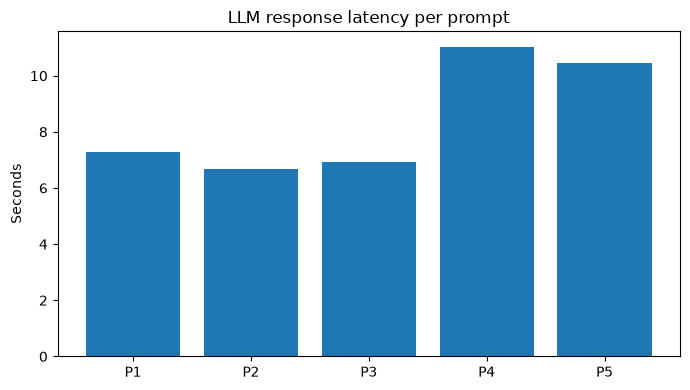

In [7]:
ok = results_df.dropna(subset=["latency_s"])
n_errors = len(results_df) - len(ok)

print(f"Calls: {len(results_df)}   Errors: {n_errors}   Error rate: {n_errors/len(results_df)*100:.0f}%")
if not ok.empty:
    print(f"Latency  — mean: {ok['latency_s'].mean():.2f}s   p95: {sorted(ok['latency_s'])[int(0.95*(len(ok)-1))]:.2f}s   max: {ok['latency_s'].max():.2f}s")
    print(f"Throughput — mean: {ok['words_per_sec'].mean():.1f} words/s")

    plt.figure(figsize=(7, 4))
    plt.bar(range(len(ok)), ok["latency_s"])
    plt.xticks(range(len(ok)), [f"P{i+1}" for i in range(len(ok))])
    plt.ylabel("Seconds")
    plt.title("LLM response latency per prompt")
    plt.tight_layout()
    plt.show()